#### Name: 

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [1]:
# put all import statements here
import math
import numpy as np
import matplotlib.pyplot as plt 
import time 

## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

Doing the derivative

$\frac{d}{dx} e^{x-\sqrt{x}}-x$


$e^{x-\sqrt{x}} \frac{d}{dx}(x-\sqrt{x}) - 1$


$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $


In [ ]:
# part 1

#making the user def functions 
def f(x):
    return np.exp(x-np.sqrt(x))-x

def df(x):
    return np.exp(x-np.sqrt(x)) * (1-(1/(2*np.sqrt(x))))-1


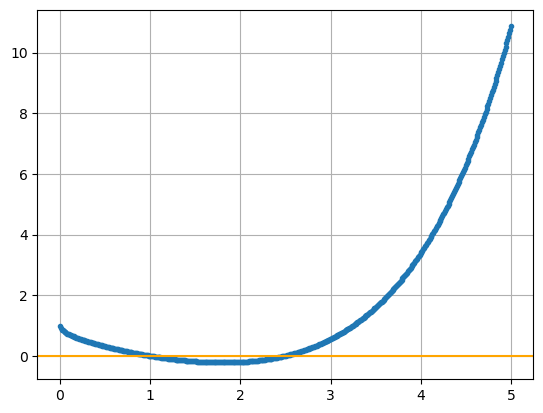

In [ ]:
# part 2

# creating an array of x values so we can plot them on the graph
x_val = np.linspace(0,5,500)
#f(x) values which are plotted on the y axis
y_val = f(x_val)

plt.plot(x_val, y_val, '.')
#horizontal line that starts at y =0
plt.axhline(0, color="orange")
plt.grid()


In [ ]:
# part 3
#guessing where the function hits zero
x_guess = np.array([0.98,2.31])
x_0 = np.copy(x_guess)



In [ ]:
# part 4

accuracy = 1e-11 #how close we want the solution to be to the root

err = 1.0 #ensures the loop keepings running

while err > accuracy:
    delta = f(x_guess)/df(x_guess) #newton correction
    x_guess -= delta # update the guess so it moves closer to the actual root
    err = max(np.abs(delta))

print(x_guess)
print(x_0)

[1.         2.49090932]
[0.98 2.31]


started off by finding the derivative of the function and writing two user def functions for f(x) and df(x). We need an array of x values to show on the graph so we had to create that. We want to y axis to be f(x) so calculating that with the x values and we were able to make the graph. Guessing what the roots could be and using those guesses to find the actual roots. we need the guesses so the code has some starting point and can run through the options until it hits the roots.

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

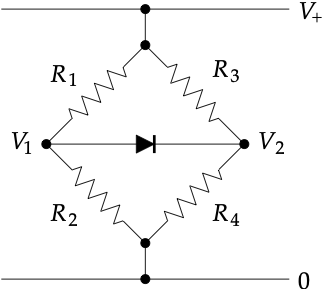

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

### part 1

the sum of the currents leaving $V_2$ is zero

through $R_3$

$\frac{V_2 -V_{+}}{R_3}$

through $R_4$

$\frac{V_2}{R_4}$

We flip the sign of $I_0$ and put it all together

$\frac{V_2 -V_{+}}{R_3} + \frac{V_2}{R_4} - I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr]$


In [ ]:
# part 3

#define the variables first

V_plus = 5 #V
R1 = 1000 #ohms
R2 = 4000 #ohms
R3 = 3000 #ohms
R4 = 2000 #ohms

I_0 = 3e-9 #amps
V_t = 0.05 #V


#the functions for the variables
def f1(V1,V2):
    return (V1-V_plus)/R1 + V1/R2 + I_0*(np.exp((V1-V2)/V_t)-1)

def f2(V1,V2):
    return (V2-V_plus)/R3 + V2/R4 - I_0*(np.exp((V1-V2)/V_t)-1)


accuracy = 1e-10

err = 9999

#making my life easier

V1= 2.0
V2= 1.0
E = np.exp((V1-V2)/V_t)

#setting up the matrix by taking the partials of the functions with respect to both voltages

a = 1/R1 + 1/R2 + I_0/V_t * E
b = -I_0/V_t * E
c = -I_0/V_t * E
d = 1/R3 + 1/R4 + I_0/V_t * E

#from class
while err > accuracy:
    A = np.array([[a,b],
                  [c,d]], float)
    
    v = np.array([f1(V1,V2), f2(V1,V2)], float)
    values = np.linalg.solve(A,v)

    V1 -= values[0]
    V2 -= values[1]

    

    err = np.sqrt(values[0]**2 * values[1]**2)


print(V1,V2)




3.4591071662163966 2.811339250675405




I was able to get the values and the difference between them is about 0.6 so everything works and matches what we expected. 